In [1]:
import matplotlib.pyplot as plt
import numpy as np
import petab
import pandas as pd
import seaborn as sns

from cytof import get_samples
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK__logobs"

# updated load_petab_base_files takes in a Conf object as argument
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)
# Get the list of all cell-lines APART from test cell-lines
all_samples = sorted(get_samples(conf.data, dataset="train+val"))
print(len(all_samples))

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotat

62


In [2]:
all_samples

['c184A1',
 'c184B5',
 'cAU565',
 'cBT20',
 'cBT474',
 'cBT483',
 'cBT549',
 'cCAL148',
 'cCAL51',
 'cCAL851',
 'cDU4475',
 'cEFM19',
 'cEFM192A',
 'cEVSAT',
 'cHBL100',
 'cHCC1187',
 'cHCC1395',
 'cHCC1419',
 'cHCC1428',
 'cHCC1500',
 'cHCC1569',
 'cHCC1599',
 'cHCC1806',
 'cHCC1937',
 'cHCC1954',
 'cHCC202',
 'cHCC2157',
 'cHCC2185',
 'cHCC2218',
 'cHCC3153',
 'cHCC38',
 'cHCC70',
 'cHDQP1',
 'cHs578T',
 'cJIMT1',
 'cLY2',
 'cMACLS2',
 'cMCF10A',
 'cMCF10F',
 'cMCF12A',
 'cMCF7',
 'cMDAMB134VI',
 'cMDAMB157',
 'cMDAMB175VII',
 'cMDAMB231',
 'cMDAMB361',
 'cMDAMB415',
 'cMDAMB436',
 'cMDAMB453',
 'cMDAMB468',
 'cMDAkb2',
 'cMFM223',
 'cMPE600',
 'cMX1',
 'cOCUBM',
 'cSKBR3',
 'cT47D',
 'cUACC3199',
 'cUACC812',
 'cUACC893',
 'cZR751',
 'cZR7530']

In [3]:
mat = contextualize_measurements(
    measurement_table=files["measurement_table"],
    observable_table=files["observable_table"],
    contextualization="cytof_dynamic",
    samples=all_samples,  # no cell-line subsetting - keep all
    impute=False
)
print(mat.index.nunique())

62


Added subchallenge I & II cell-lines (6+12) and restored 1 outlier + 3 cell-lines lacking transcriptomics, so the total number of rows went from 40 to 62

In [4]:
subset_to_EGF = False
if subset_to_EGF:
    mat = mat[[col for col in mat.columns if col[1] == "EGF"]]

# Toggle this to impute and keep (True) / drop (False) pHER2
impute_missing = True
if impute_missing:
    knn_imputer = KNNImputer()
    knn_imputer.fit(mat)
    mat = pd.DataFrame(
        knn_imputer.transform(mat),
        columns=mat.columns,
        index=mat.index
    )

In [5]:
perbb2 = mat.loc[:, mat.columns.get_level_values(0).str.contains("pERBB2")]
perbb2.index.name = "cell_line"   # just to have a nice name
long = (
    perbb2
      .stack(level=list(range(perbb2.columns.nlevels)))   # collapse all column levels
      .rename("value")
      .reset_index()
)

long

/var/folders/qq/j5fqpnkx00n96n4y5_rx_f7r0000gp/T/ipykernel_66923/1471188500.py:4: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  perbb2


,cell_line,observableId,simulationConditionId,time,value
0,c184A1,pERBB2_Y1248_obs,EGF,0.0,4.166056
1,c184A1,pERBB2_Y1248_obs,EGF,5.5,4.199643
2,c184A1,pERBB2_Y1248_obs,EGF,7.0,4.492903
3,c184A1,pERBB2_Y1248_obs,EGF,9.0,4.669069
4,c184A1,pERBB2_Y1248_obs,EGF,12.0,4.025686
...,...,...,...,...,...
2041,cZR7530,pERBB2_Y1248_obs,iMEK,18.0,5.256199
2042,cZR7530,pERBB2_Y1248_obs,iMEK,40.0,4.908143
2043,cZR7530,pERBB2_Y1248_obs,iMEK,60.0,5.046704
2044,cZR7530,pERBB2_Y1248_obs,iMEK,15.0,4.326176


<Axes: xlabel='observableId-simulationConditionId-time', ylabel='cell_line'>

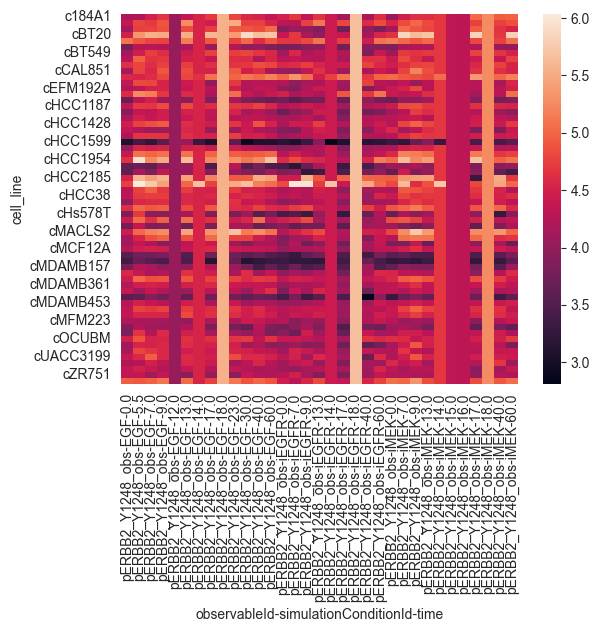

In [6]:
sns.heatmap(perbb2, xticklabels=True)

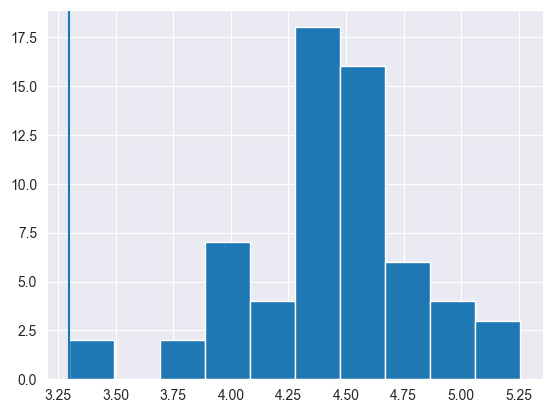

In [7]:
perbb2.median(axis=1).hist()
plt.axvline(perbb2.median(axis=1).loc["cHCC1599"])

In [8]:
mat_nonans = mat.dropna(how="any", axis=1)

In [9]:
mat_nonans.shape

(62, 138)

In [10]:
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean AFTER outlier: cHCC2185, cHCC1500, cUACC3199, cMCF7, CBT20

cell_line
cHCC1599       1.067622
cHCC2185       0.658175
cHCC1500       0.638261
cUACC3199      0.512352
cMCF7          0.507391
cBT20          0.504973
cHCC1954       0.478224
cUACC893       0.450061
cEVSAT         0.439396
cMDAMB134VI    0.348552
dtype: float64

In [11]:
print(res.sort_values(ascending=False).head(10).index.values)

['cHCC1599' 'cHCC2185' 'cHCC1500' 'cUACC3199' 'cMCF7' 'cBT20' 'cHCC1954'
 'cUACC893' 'cEVSAT' 'cMDAMB134VI']


<Axes: ylabel='Frequency'>

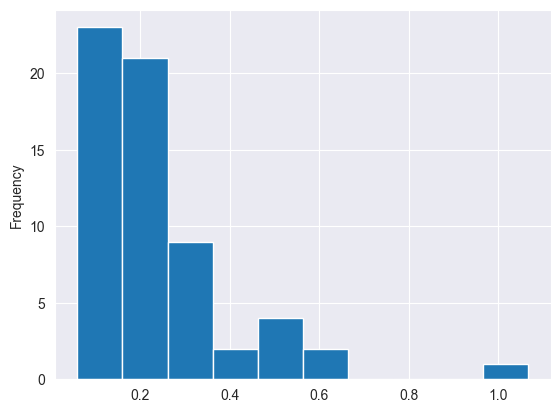

In [12]:
res.plot.hist()

In [13]:
list(res[res.values > 1.0].index)  # 'cHCC1599' is an outlier

['cHCC1599']

In [14]:
mat.drop(list(res[res.values > 1].index), axis=0, inplace=True)

In [15]:
mat.shape

(61, 138)

## After removing outlier HCC1599, mean changes so exact order of hardest cell-lines changes, but top 5 are the same cell-lines: HCC1500, HCC2185, MCF7, UACC3199 and BT20.

In [30]:
mat_nonans = mat.dropna(how="any", axis=1)
res = (mat_nonans - mat_nonans.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res.sort_values(ascending=False).head(10)

cell_line
cHCC1500       0.656381
cHCC2185       0.643421
cMCF7          0.525102
cUACC3199      0.494046
cBT20          0.484869
cUACC893       0.464885
cHCC1954       0.459812
cEVSAT         0.451926
cMDAMB134VI    0.362272
cHCC202        0.347194
dtype: float64

# Inspect PCA

In [17]:
X = mat.values
# impute missing values prior to PCA
X_imputed = KNNImputer().fit_transform(X)

pca = PCA(n_components=10)
Xt = pca.fit_transform(X_imputed)

In [18]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(61, 10)

/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


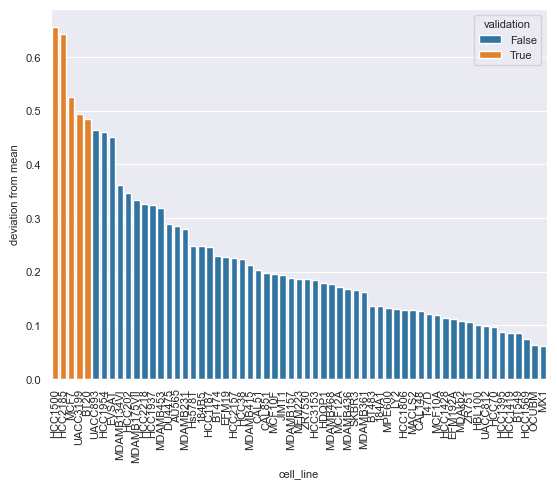

In [19]:
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(5).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [20]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,2.176881,1.267693,False
184B5,1.781411,3.924525,False
AU565,-5.233058,0.213968,False
BT20,-6.612385,2.788094,True
BT474,3.614050,3.276876,False
...,...,...,...
UACC3199,-7.497936,-1.319478,True
UACC812,2.067644,-0.178504,False
UACC893,7.434163,0.921349,False


In [31]:
# Manually define annotation offsets to be able to read cell-line names
offsets = {
    # "HCC1599": {"ox": -1.7, "oy": -0.2},
    "MCF7": {"ox": -1.7, "oy": -0.2},
    "HCC1500": {"ox": 0.4, "oy": -0.2},
    "BT20": {"ox": 0.3, "oy": -0.2},
    "HCC2185": {"ox": 0.3, "oy": 0},
    "UACC3199": {"ox": -0.3, "oy": -0.5},
    "UACC893": {"ox": -0.3, "oy": -0.5},
    "HCC1954": {"ox": -0.3, "oy": -0.5},
    "EVSAT": {"ox": -0.3, "oy": -0.5},
}

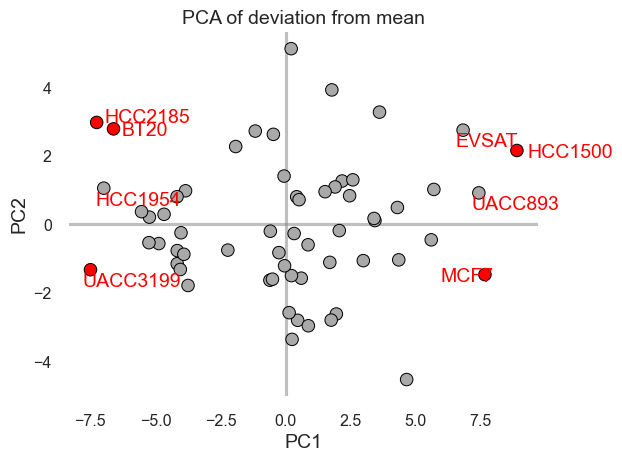

In [33]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation",
    palette={True: "red", False: "darkgray"},
    edgecolor="black",
    legend=False
)
# add red colour for validation cell-lines
for _, r in df.iterrows():
    if r.validation or r.name in offsets.keys():
        plt.annotate(r.name, (r.PC1+offsets[r.name]["ox"], r.PC2+offsets[r.name]["oy"]), color="red", fontsize=14)

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low order to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
# g.set(xlim=(-7.2, 7.2), ylim=(-5, 5), aspect=1.0, xticks=[], yticks=[])
g.set_xlabel("PC1", fontsize=14)
g.set_ylabel("PC2", fontsize=14)
#
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
VE = sum(pca.explained_variance_ratio_[:2])
# plt.title(f"PCA of deviance from mean ({VE*100:.0f}% Variance Explained)")
plt.title(f"PCA of deviation from mean", fontsize=14)
plt.tight_layout()
# plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [23]:
res_df = res.reset_index()
res_df["cell_line"] = res_df["cell_line"].apply(lambda x: x[1:])

scatter_df = df.reset_index().merge(res_df, on="cell_line", how="left")


In [24]:
pca.explained_variance_ratio_

array([0.48448235, 0.11183649, 0.08712129, 0.06527726, 0.05201161,
       0.03351371, 0.02360194, 0.01752812, 0.01361168, 0.01213693])

In [25]:
pca.components_.shape

(10, 138)

In [26]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

observableId          pERBB2_Y1248_obs                                \
simulationConditionId              EGF                                 
time                              0.0       5.5       7.0       9.0    
PC0                          -0.027681 -0.056956 -0.055255 -0.065963   
PC1                           0.138395  0.157579  0.163875  0.163998   

observableId                                                       \
simulationConditionId                                               
time                           12.0      13.0      14.0      17.0   
PC0                    1.091984e-17 -0.059259  0.000128 -0.065335   
PC1                    8.874313e-17  0.175250  0.028820  0.152912   

observableId                                   ... pRPS6KA1_S380_obs  \
simulationConditionId                          ...              iMEK   
time                           18.0      23.0  ...              9.0    
PC0                    7.564435e-17 -0.047252  ...         -0.132969   
PC1                   -8.388529e-17  0.177719  ...          0.052962   

observableId                                                           \
simulationConditionId                                                   
time                           12.0      13.0      14.0          15.0   
PC0                   -1.352850e-31 -0.134807 -0.000459 -6.764251e-32   
PC1                    6.920817e-32 -0.032265  0.010385  3.460409e-32   

observableId                                                           \
simulationConditionId                                                   
time                           16.0      17.0          18.0      40.0   
PC0                   -6.764251e-32 -0.127978 -6.764251e-32 -0.148136   
PC1                    3.460409e-32  0.019198  3.460409e-32  0.016933   

observableId                     
simulationConditionId            
time                       60.0  
PC0                   -0.124383  
PC1                    0.068472  

[2 rows x 138 columns]

In [27]:
pc_mat.reset_index().columns

MultiIndex([(            'index',     '',   ''),
            ( 'pERBB2_Y1248_obs',  'EGF',  0.0),
            ( 'pERBB2_Y1248_obs',  'EGF',  5.5),
            ( 'pERBB2_Y1248_obs',  'EGF',  7.0),
            ( 'pERBB2_Y1248_obs',  'EGF',  9.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 12.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 13.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 14.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 17.0),
            ( 'pERBB2_Y1248_obs',  'EGF', 18.0),
            ...
            ('pRPS6KA1_S380_obs', 'iMEK',  9.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 12.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 13.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 14.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 15.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 16.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 17.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 18.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 40.0),
            ('pRPS6KA1_S380_obs', 'iMEK', 60.0)],
   

In [28]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars=[("index", "", "")])
pc_mat_long

,"(index, , )",observableId,simulationConditionId,time,value
0,PC0,pERBB2_Y1248_obs,EGF,0.0,-2.768142e-02
1,PC1,pERBB2_Y1248_obs,EGF,0.0,1.383949e-01
2,PC0,pERBB2_Y1248_obs,EGF,5.5,-5.695645e-02
3,PC1,pERBB2_Y1248_obs,EGF,5.5,1.575789e-01
4,PC0,pERBB2_Y1248_obs,EGF,7.0,-5.525451e-02
...,...,...,...,...,...
271,PC1,pRPS6KA1_S380_obs,iMEK,18.0,3.460409e-32
272,PC0,pRPS6KA1_S380_obs,iMEK,40.0,-1.481357e-01
273,PC1,pRPS6KA1_S380_obs,iMEK,40.0,1.693331e-02
274,PC0,pRPS6KA1_S380_obs,iMEK,60.0,-1.243826e-01


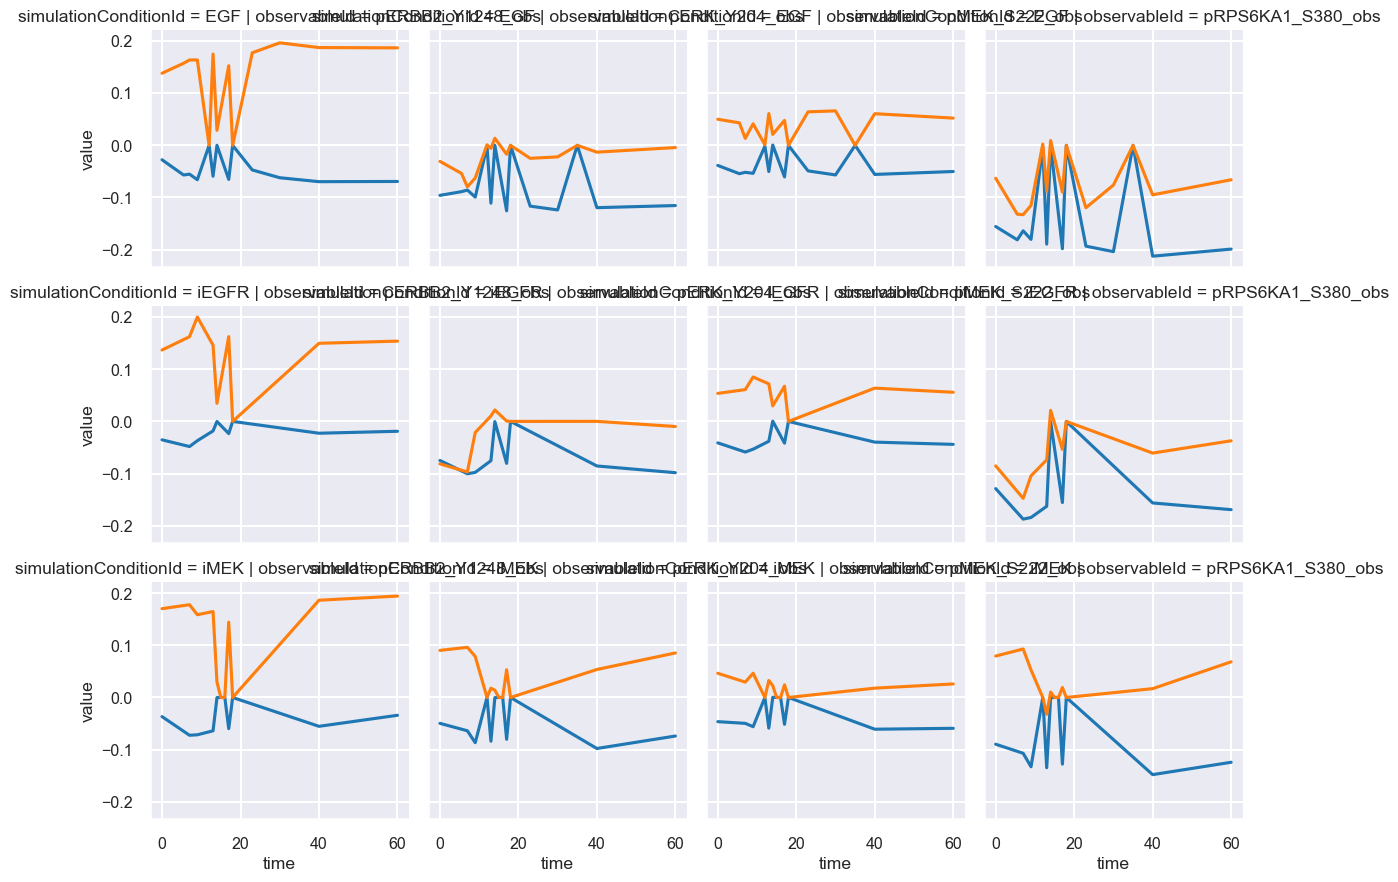

In [29]:
g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="simulationConditionId", hue=("index", "", "")
)
g.map_dataframe(sns.lineplot, x="time", y="value")
# Previous notebook showed 5 perturbation, but we have now removed iPI3K and iPKC -> 3 left (EGF, iEGFR, iMEK)